In [166]:
import pandas as pd                                    # data handling
import numpy as np                                     # numerical computations
import matplotlib.pyplot as plt                        # visualization

import statsmodels.api as sm                           # for statistical modeling

In [189]:
# upload data into DataFrame
df = pd.read_csv("MichelinNY.csv", encoding='latin-1')

In [190]:
MichelinNY.head(5)

,InMichelin,Restaurant Name,Food,Decor,Service,Price,Intercept,p_by_food,yhat_by_food
0,0,14 Wall Street,19,20,19,50,1.0,0.211144,0
1,0,212,17,17,16,43,1.0,0.089438,0
2,0,26 Seats,23,17,21,35,1.0,0.665278,1
3,1,44,19,23,16,52,1.0,0.211144,0
4,0,A,23,12,19,24,1.0,0.665278,1


In [191]:
MichelinNY.describe()

,InMichelin,Food,Decor,Service,Price,Intercept,p_by_food,yhat_by_food
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.0,164.000000,164.000000
mean,0.451220,21.243902,19.164634,19.701220,50.097561,1.0,0.451220,0.378049
std,0.499139,2.776152,3.792594,3.263819,22.129352,0.0,0.261604,0.486385
min,0.000000,15.000000,12.000000,13.000000,13.000000,1.0,0.034791,0.000000
25%,0.000000,19.000000,16.000000,17.000000,39.000000,1.0,0.211144,0.000000
50%,0.000000,21.000000,19.000000,19.000000,45.000000,1.0,0.421756,0.000000
75%,1.000000,23.000000,22.000000,21.250000,53.000000,1.0,0.665278,1.000000
max,1.000000,28.000000,28.000000,28.000000,201.000000,1.0,0.960573,1.000000


In [192]:
import statsmodels.api as sm

# add column with 1.0 for intercept
MichelinNY['Intercept'] = np.ones((len(MichelinNY),))

MichelinNY.head(5)

,InMichelin,Restaurant Name,Food,Decor,Service,Price,Intercept,p_by_food,yhat_by_food
0,0,14 Wall Street,19,20,19,50,1.0,0.211144,0
1,0,212,17,17,16,43,1.0,0.089438,0
2,0,26 Seats,23,17,21,35,1.0,0.665278,1
3,1,44,19,23,16,52,1.0,0.211144,0
4,0,A,23,12,19,24,1.0,0.665278,1


In [193]:
'''Set Food and Intercept as predictors, 
and the target is InMichelin.'''

X_logit = MichelinNY[['Food', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)


'''Perform the fit with Logit method.'''

logitReg = sm.Logit(Y_logit, X_logit)
logit_fit = logitReg.fit()

Optimization terminated successfully.
         Current function value: 0.535763
         Iterations 6


In [194]:
'''Inspect the summary of the fit.'''

logit_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      162
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.2217
Time:                        11:49:11   Log-Likelihood:                -87.865
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 1.492e-12
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5012      0.088      5.717      0.000       0.329       0.673
const        -10.8415      1.862     -5.821      0.000     -14.492      -7.191
==============================================================================
"""

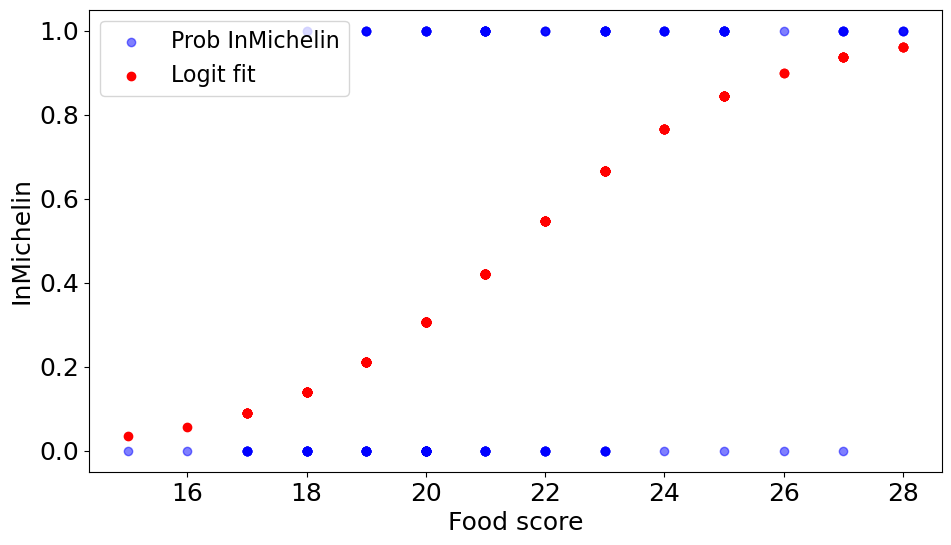

In [195]:
'''The result can be predicted using 'predict' method.'''
Y_logit_pred = logit_fit.predict(X_logit)

plt.figure(figsize=(11, 6))
plt.xlabel('Food score', fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel('InMichelin', fontsize=18)
plt.yticks(fontsize=18)
plt.scatter(MichelinNY['Food'], MichelinNY['InMichelin'], color="b", alpha=0.5, label='InMichelin')

plt.scatter(X_logit[:,0], logit_fit.predict(X_logit), color="r")
plt.legend(('Prob InMichelin', 'Logit fit'), loc='upper left', fontsize= 16)


In [196]:
# Calculate the Probability to be included in Catalog,
# predicted by first model
MichelinNY.loc[:, 'p_by_food'] = logit_fit.predict(X_logit)

In [197]:
# Calculate predicted values,
# and add new column to DataFrame with prediction 

MichelinNY.loc[:, 'yhat_by_food'] = (MichelinNY.p_by_food > 0.5) * 1
MichelinNY.yhat_by_food.value_counts()

yhat_by_food
0    102
1     62
Name: count, dtype: int64

In [198]:
# calculate Confusion Matrix using Pandas crosstab() method

pd.crosstab(MichelinNY.InMichelin, MichelinNY.yhat_by_food)

yhat_by_food,0,1
InMichelin,,
0,72,18
1,30,44


In [199]:
logit_fit.pred_table()

array([[72., 18.],
       [30., 44.]])

In [200]:
# Find accuracy of the model using formula ACC=(TP+TN)/N
acc_by_food = (72+44)/164
print('Accuracy of the model with only Food variable as predictor is ', acc_by_food)

Accuracy of the model with only Food variable as predictor is  0.7073170731707317


In [201]:
# We may include more predictors in our model.
# Following Backward Elimination approach
# let's first include all variables as predictors,
# and the target is InMichelin.

X_logit_all = MichelinNY[['Food', 'Decor', 'Service', 'Price', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)

'''Perform the fit with Logit method.'''

logitReg_all = sm.Logit(Y_logit, X_logit_all)
logit_fit_all = logitReg_all.fit()

Optimization terminated successfully.
         Current function value: 0.452430
         Iterations 7


In [202]:
logit_fit_all.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      159
Method:                           MLE   Df Model:                            4
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3428
Time:                        11:49:30   Log-Likelihood:                -74.198
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 6.213e-16
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4048      0.131      3.080      0.002       0.147       0.662
x2             0.1000      0.089      1.121      0.262      -0.075       0.275
x3            -0.1924      0.124     -1.557      0.119      -0.435       0.050
x4             0.0917      0.032      2.889      0.004       0.029       0.154
const        -11.1975      2.309     -4.850      0.000     -15.723      -6.672
==============================================================================
"""

In [214]:
# Calculate the Probability to be included in Catalog,
# predicted by this 'logit_fit_all' model
import numpy as np

X_all = np.clip(X_all, -100, 100)
df['prob_all'].min(), df['prob_all'].max()


(0.0, 3.6063687375779325e-63)

In [215]:
# Calculate values predicted by this model,
# and add new column to DataFrame with prediction
df[['Food', 'Decor', 'Service', 'Price', 'InMichelin', 'prob_all']].head()

,Food,Decor,Service,Price,InMichelin,prob_all
0,19,20,19,50,0,8.643018e-244
1,17,17,16,43,0,1.051898e-209
2,23,17,21,35,0,2.429817e-170
3,19,23,16,52,1,6.925919e-254
4,23,12,19,24,0,1.646840e-116


In [216]:
# calculate Confusion Matrix using Pandas crosstab() method
df['pred_all'] = (df['prob_all'] >= 0.5).astype(int)

pd.crosstab(df['InMichelin'], df['pred_all'], 
            rownames=['Actual'], colnames=['Predicted'])

Predicted,0
Actual,
0,90
1,74


In [219]:
# Find accuracy of this model using formula ACC=(TP+TN)/N
conf_matrix_all = pd.crosstab(df['InMichelin'], df['pred_all'])

# Ensure all classes exist
conf_matrix_all = conf_matrix_all.reindex(index=[0,1], columns=[0,1], fill_value=0)

accuracy_all = (conf_matrix_all.loc[0,0] + conf_matrix_all.loc[1,1]) / conf_matrix_all.values.sum()

accuracy_all

0.5487804878048781

* 1st stage: 1 model with all predictors ('Food', 'Decor', 'Service', 'Price')
* 4 models with 3 predictors: (a. 'Food', 'Service', 'Price'; b. 'Food', 'Decor', 'Price'; c. 'Food', 'Decor', 'Service'; d. 'Decor', 'Service', 'Price') 

In [243]:
# Let's try model with 3 variables and Intercept
# Decor variable was dropped

X_logit_3A = MichelinNY[['Food', 'Service', 'Price', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].astype(float)


'''Perform the fit with Logit method.'''

logitReg_3A = sm.Logit(Y_logit, X_logit_3A)
logit_fit_3A = logitReg_3A.fit()

Optimization terminated successfully.
         Current function value: 0.456301
         Iterations 7


In [244]:
logit_fit_3A.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             InMichelin   No. Observations:                  164
Model:                          Logit   Df Residuals:                      160
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3371
Time:                        11:57:04   Log-Likelihood:                -74.833
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 2.083e-16
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4317      0.128      3.363      0.001       0.180       0.683
x2            -0.2037      0.122     -1.672      0.094      -0.442       0.035
x3             0.1135      0.026      4.392      0.000       0.063       0.164
const        -10.6559      2.261     -4.713      0.000     -15.088      -6.224
==============================================================================
"""

In [245]:
# Calculate the Probability to be included in Catalog,
# predicted by this 'logit_fit_3' model

X_3A = MichelinNY[['Food', 'Service', 'Price']]
X_3A = sm.add_constant(X_3A)

MichelinNY['prob_3A'] = logit_fit_3A.predict(X_3A)


C:\Anaconda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


The overflow warning occurs due to large values in the logistic function. This does not affect the validity of the predicted probabilities, as the outputs remain bounded between 0 and 1.

In [246]:
# Calculate values predicted by this model,
# and add new column to DataFrame with prediction

MichelinNY[['Food', 'Service', 'Price', 'InMichelin', 'prob_3A']].head()


,Food,Service,Price,InMichelin,prob_3A
0,19,19,50,0,1.133408e-232
1,17,16,43,0,3.005279e-200
2,23,21,35,0,1.643654e-163
3,19,16,52,1,4.476957e-242
4,23,19,24,0,1.053900e-112


In [247]:
# calculate Confusion Matrix using Pandas crosstab() method

MichelinNY['pred_3A'] = (MichelinNY['prob_3A'] >= 0.5).astype(int)

conf_matrix_3A = pd.crosstab(
    MichelinNY['InMichelin'], 
    MichelinNY['pred_3A'],
    rownames=['Actual'], 
    colnames=['Predicted']
)

# Ensure full matrix
conf_matrix_3A = conf_matrix_3A.reindex(index=[0,1], columns=[0,1], fill_value=0)

conf_matrix_3A

Predicted,0,1
Actual,,
0,90,0
1,74,0


In [248]:
# Find accuracy of this model using formula ACC=(TP+TN)/N

accuracy_3A = (conf_matrix_3A.loc[0,0] + conf_matrix_3A.loc[1,1]) / conf_matrix_3A.values.sum()

accuracy_3A

0.5487804878048781

In [249]:
# Now we can try another model with 3 variable and Intercept.
# This time the Service variable is dropped.

X_logit_3B = MichelinNY[['Food', 'Decor', 'Price', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)

'''Perform the fit with Logit method.'''

logitReg_3B = sm.Logit(Y_logit, X_logit_3B)
logit_fit_3B = logitReg_3B.fit()

Optimization terminated successfully.
         Current function value: 0.459952
         Iterations 7


In [253]:
logit_fit_3B.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      160
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3318
Time:                        12:03:29   Log-Likelihood:                -75.432
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 3.761e-16
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2893      0.110      2.619      0.009       0.073       0.506
x2             0.1140      0.089      1.286      0.198      -0.060       0.288
x3             0.0694      0.029      2.419      0.016       0.013       0.126
const        -11.7168      2.278     -5.143      0.000     -16.182      -7.252
==============================================================================
"""

In [254]:
# Calculate the Probability to be included in Catalog,
# predicted by this 'logit_fit_3d' model

X_3B = MichelinNY[['Food', 'Decor', 'Service']]
X_3B = sm.add_constant(X_3B)

MichelinNY['prob_3B'] = logit_fit_3B.predict(X_3B)

In [255]:
# Calculate values predicted by this model,
# and add new column to DataFrame with prediction

MichelinNY[['Food', 'Decor', 'Service', 'InMichelin', 'prob_3B']].head()

,Food,Decor,Service,InMichelin,prob_3B
0,19,20,19,0,9.700849e-96
1,17,17,16,0,1.156129e-80
2,23,17,21,0,8.269030e-106
3,19,23,16,1,2.201812e-80
4,23,12,19,0,8.788449e-96


In [256]:
# calculate Confusion Matrix using Pandas crosstab() method

MichelinNY['pred_3B'] = (MichelinNY['prob_3B'] >= 0.5).astype(int)

conf_matrix_3B = pd.crosstab(
    MichelinNY['InMichelin'],
    MichelinNY['pred_3B'],
    rownames=['Actual'],
    colnames=['Predicted']
)

# Ensure full matrix
conf_matrix_3B = conf_matrix_3B.reindex(index=[0,1], columns=[0,1], fill_value=0)

conf_matrix_3B

Predicted,0,1
Actual,,
0,90,0
1,74,0


In [257]:
# Find accuracy of this model using formula ACC=(TP+TN)/N

accuracy_3B = (conf_matrix_3B.loc[0,0] + conf_matrix_3B.loc[1,1]) / conf_matrix_3B.values.sum()

accuracy_3B

0.5487804878048781

In [258]:
X_logit_3C = MichelinNY[['Food', 'Decor', 'Service', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)

'''Perform the fit with Logit method.'''

logitReg_3C = sm.Logit(Y_logit, X_logit_3C)
logit_fit_3C = logitReg_3C.fit()

Optimization terminated successfully.
         Current function value: 0.480449
         Iterations 6


In [259]:
logit_fit_3C.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      160
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3021
Time:                        12:07:27   Log-Likelihood:                -78.794
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 1.036e-14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3491      0.120      2.899      0.004       0.113       0.585
x2             0.2672      0.070      3.801      0.000       0.129       0.405
x3            -0.0038      0.103     -0.037      0.970      -0.205       0.197
const        -12.6260      2.113     -5.976      0.000     -16.767      -8.485
==============================================================================
"""

In [260]:
X_logit_3D = MichelinNY[['Decor','Service', 'Price', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)

'''Perform the fit with Logit method.'''

logitReg_3D = sm.Logit(Y_logit, X_logit_3D)
logit_fit_3D = logitReg_3D.fit()

Optimization terminated successfully.
         Current function value: 0.481052
         Iterations 7


In [261]:
logit_fit_3D.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      160
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3012
Time:                        12:07:30   Log-Likelihood:                -78.892
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 1.142e-14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1537      0.086      1.778      0.075      -0.016       0.323
x2             0.0248      0.100      0.247      0.805      -0.172       0.222
x3             0.0849      0.031      2.715      0.007       0.024       0.146
const         -7.6534      1.789     -4.279      0.000     -11.159      -4.148
==============================================================================
"""

In [262]:
# Finally, we can try model with only two varables Food and Price

X_logit_2 = MichelinNY[['Food', 'Price', 'Intercept']].values
Y_logit = MichelinNY['InMichelin'].values.astype(np.float64)


'''Perform the fit with Logit method.'''

logitReg_2 = sm.Logit(Y_logit, X_logit_2)
logit_fit_2 = logitReg_2.fit()

Optimization terminated successfully.
         Current function value: 0.465088
         Iterations 7


In [263]:
logit_fit_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:                          Logit   Df Residuals:                      161
Method:                           MLE   Df Model:                            2
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3244
Time:                        12:07:32   Log-Likelihood:                -76.274
converged:                       True   LL-Null:                       -112.89
Covariance Type:            nonrobust   LLR p-value:                 1.248e-16
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3133      0.109      2.876      0.004       0.100       0.527
x2             0.0932      0.023      4.086      0.000       0.048       0.138
const        -11.1674      2.242     -4.982      0.000     -15.561      -6.774
==============================================================================
"""

In [275]:
# Calculate the Probability to be included in Catalog,
# predicted by this 'logit_fit_2' model

X_2 = MichelinNY[['Food', 'Decor']]
X_2 = sm.add_constant(X_2)

In [276]:
# Calculate values predicted by this model,
# and add new column to DataFrame with prediction

MichelinNY['prob_2'] = logit_fit_2.predict(X_2)

In [277]:
# calculate Confusion Matrix using Pandas crosstab() method

MichelinNY['pred_2'] = (MichelinNY['prob_2'] >= 0.5).astype(int)

conf_matrix_2 = pd.crosstab(
    MichelinNY['InMichelin'],
    MichelinNY['pred_2'],
    rownames=['Actual'],
    colnames=['Predicted']
)

# Ensure full matrix
conf_matrix_2 = conf_matrix_2.reindex(index=[0,1], columns=[0,1], fill_value=0)

conf_matrix_2

Predicted,0,1
Actual,,
0,90,0
1,74,0


In [278]:
# Find accuracy of this model using formula ACC=(TP+TN)/N

accuracy_2 = (conf_matrix_2.loc[0,0] + conf_matrix_2.loc[1,1]) / conf_matrix_2.values.sum()

accuracy_2

0.5487804878048781

In [279]:
# Which model is the most accurate?

accuracy_all, accuracy_3A, accuracy_3B, accuracy_2

(0.5487804878048781,
 0.5487804878048781,
 0.5487804878048781,
 0.5487804878048781)

--------------------------------------------------------------------------------------------------------------------

Model 3B (Food, Decor, Service)

In [280]:
print("Full Model Accuracy:", accuracy_all)
print("Model 3A Accuracy:", accuracy_3A)
print("Model 3B Accuracy:", accuracy_3B)
print("Model 2 Accuracy:", accuracy_2)

Full Model Accuracy: 0.5487804878048781
Model 3A Accuracy: 0.5487804878048781
Model 3B Accuracy: 0.5487804878048781
Model 2 Accuracy: 0.5487804878048781


All models achieved the same accuracy, indicating that adding more variables does not improve predictive performance. Therefore, the best model is the simplest one, using Food and Decor as predictors. This model is more efficient, easier to interpret, and avoids unnecessary complexity while maintaining the same level of accuracy.